**Analisi sul nuoto**

In [ ]:
# importo il file
from google.colab import files
uploaded = files.upload()

Saving swimming.csv to swimming.csv


In [ ]:
# importo le librerie da utilizzare
import pandas as pd
import re
import numpy as np

In [ ]:
# leggo il dataset
df = pd.read_csv("swimming.csv")
df.head()

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4


In [ ]:
def clean_swim_time(val):
    if pd.isna(val):
        return np.nan, None

    v = str(val).strip().lower()

    # 🚫 status
    if 'disqual' in v:
        return np.nan, 'DQ'
    if 'did not start' in v:
        return np.nan, 'DNS'
    if 'did not finish' in v:
        return np.nan, 'DNF'

    try:
        # 🔥 Caso 1: formato tipo 00:14:39.480000
        if v.count(':') == 2:
            h, m, s = v.split(':')
            total_sec = int(h)*3600 + int(m)*60 + float(s)
            return total_sec, f"{int(m)}:{float(s):05.2f}"

        # 🔥 Caso 2: formato mm:ss.xx
        if v.count(':') == 1:
            m, s = v.split(':')
            total_sec = float(m)*60 + float(s)
            return total_sec, f"{int(m)}:{float(s):05.2f}"

        # 🔥 Caso 3: formato strano tipo 70.20.00
        if v.count('.') == 2:
            parts = v.split('.')
            m = float(parts[0])
            s = float(parts[1] + '.' + parts[2])
            total_sec = m*60 + s
            return total_sec, f"{int(m)}:{s:05.2f}"

        # 🔥 Caso 4: secondi normali
        sec = float(v)
        return sec, f"{sec:.2f}"

    except:
        return np.nan, 'INVALID'

In [ ]:
df[['time_seconds', 'time_display']] = df['Results'].apply(
    lambda x: pd.Series(clean_swim_time(x))
)

In [ ]:
df['time_seconds'].isna().sum()

np.int64(133)

In [ ]:
df[df['time_display'].isin(['INVALID'])]

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,time_seconds,time_display
4255,Antwerp,1920,1500m,Freestyle,0,Men,CAN,George Vernot,22:36.4est,2,NaN,INVALID
4256,Antwerp,1920,1500m,Freestyle,0,Men,AUS,Frank De Beaurepaire,23:04.0est,3,NaN,INVALID
4257,Antwerp,1920,1500m,Freestyle,0,Men,USA,Fred Kahele,23:59.1est,4,NaN,INVALID
4258,Antwerp,1920,1500m,Freestyle,0,Men,USA,Eugene Bolden,24:04.3est,4,NaN,INVALID


In [ ]:
df['status'] = df['time_display'].replace({
    'DQ': 'disqualified',
    'DNS': 'not_started',
    'DNF': 'not_finished'
}).fillna('valid')

In [ ]:
df.head(1000)

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,time_seconds,time_display,status
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1,51.98,51.98,51.98
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2,52.00,52.00,52.00
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3,52.19,52.19,52.19
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4,52.30,52.30,52.30
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4,52.51,52.51,52.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Athens,2004,100m,Backstroke,0,Men,USA,Lenny Krayzelburg,54.380,4,54.38,54.38,54.38
996,Athens,2004,100m,Backstroke,0,Men,AUS,Matthew Welsh,54.520,4,54.52,54.52,54.52
997,Athens,2004,100m,Backstroke,0,Men,HUN,Laszlo Cseh,54.610,4,54.61,54.61,54.61
998,Athens,2004,100m,Backstroke,0,Men,GER,Steffen Driesen,54.630,4,54.63,54.63,54.63


In [ ]:
#scarico il file per google sheet
df.to_csv('swimming_cleaned.csv', index=False)
files.download('swimming_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **PREDIZIONE**

/tmp/ipykernel_12143/1869524965.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["time_seconds"] = pd.to_numeric(df_filtered["time_seconds"], errors="coerce")
/tmp/ipykernel_12143/1869524965.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Year"] = pd.to_numeric(df_filtered["Year"], errors="coerce")


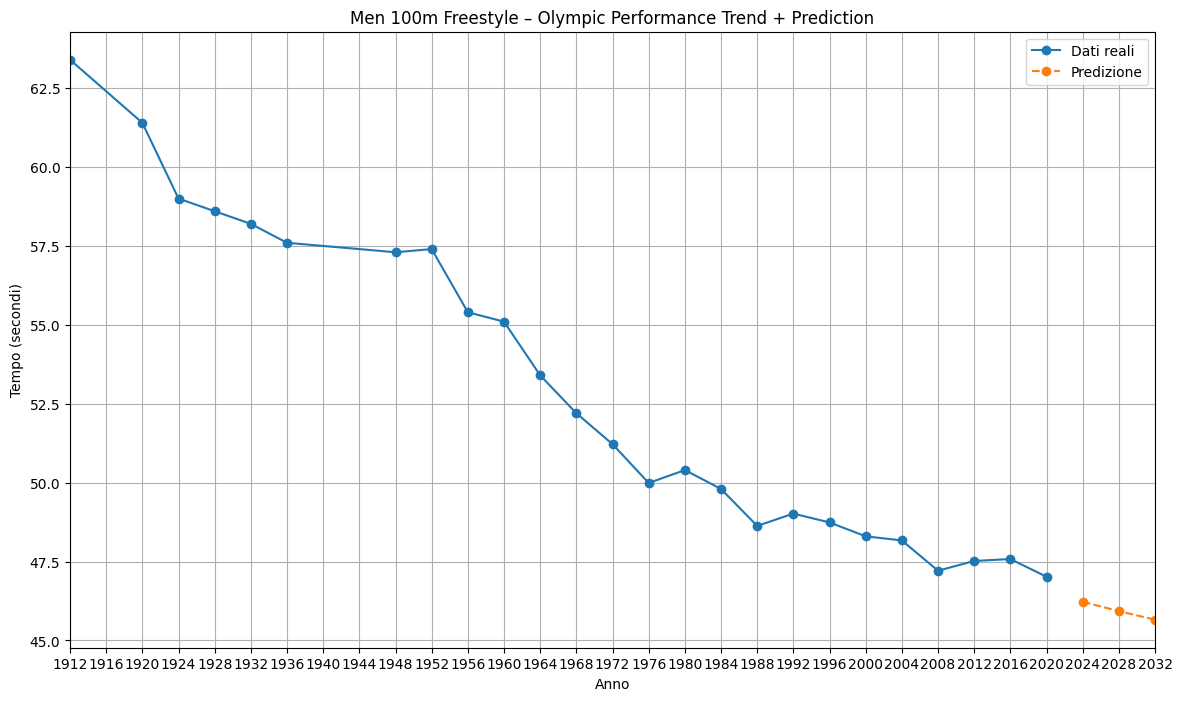


Predizioni:
2024: 46.22 sec
2028: 45.93 sec
2032: 45.66 sec


In [ ]:
# 📦 LIBRERIE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 📂 CARICA FILE
df = pd.read_csv("/content/swimming_cleaned.csv")

# 🔍 FILTRI
df_filtered = df[
    (df["Distance (in meters)"] == "100m") &
    (df["Stroke"] == "Freestyle") &
    (df["Gender"] == "Men")
]

# 🔢 CONVERSIONE SICURA
df_filtered["time_seconds"] = pd.to_numeric(df_filtered["time_seconds"], errors="coerce")
df_filtered["Year"] = pd.to_numeric(df_filtered["Year"], errors="coerce")

# 🧹 RIMUOVI VALORI NULL
df_filtered = df_filtered.dropna(subset=["time_seconds", "Year"])

# 🏆 MIGLIOR TEMPO PER ANNO (FIX PRINCIPALE)
df_best = df_filtered.groupby("Year", as_index=False)["time_seconds"].min()

# 📊 DATI MODELLO
X = df_best["Year"].values.reshape(-1, 1)
y = df_best["time_seconds"].values

# 🔮 MODELLO POLINOMIALE
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# 🔮 ANNI FUTURI (OLIMPIADI)
future_years = np.array([2024, 2028, 2032]).reshape(-1, 1)
future_poly = poly.transform(future_years)
predictions = model.predict(future_poly)

# 📈 GRAFICO
plt.figure(figsize=(14,8))

# linea reale
plt.plot(df_best["Year"], y, marker='o', label="Dati reali")

# linea predizione
plt.plot(future_years, predictions, linestyle='dashed', marker='o', label="Predizione")

# asse X corretto
all_years = list(df_best["Year"]) + list(future_years.flatten())
plt.xticks(range(int(min(all_years)), 2033, 4))
plt.xlim(min(all_years), 2032)

# stile
plt.xlabel("Anno")
plt.ylabel("Tempo (secondi)")
plt.title("Men 100m Freestyle – Olympic Performance Trend + Prediction")
plt.legend()
plt.grid()

plt.show()

# 📊 OUTPUT NUMERICO
print("\nPredizioni:")
for year, pred in zip(future_years.flatten(), predictions):
    print(f"{year}: {round(pred,2)} sec")